Load the Processed Feature Store

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load processed feature dataset from Phase 2
df = pd.read_csv("../data/processed/processed_student_features.csv")

print(
    f"Dataset loaded successfully! Shape: {df.shape[0]:,} rows x {df.shape[1]} columns"
)
df.head()

Dataset loaded successfully! Shape: 40,000 rows x 20 columns


,student_id,first_generation,pell_eligible,credits_attempted,term_gpa,lms_logins_per_week,advisor_visits,financial_hold,at_risk,probation_risk,low_lms_engagement,vulnerability_index,ethnicity_Black / African American,ethnicity_Hispanic / Latino,ethnicity_Other / International,ethnicity_Two or More Races,ethnicity_White,enrollment_pathway_Transfer,residency_status_International,residency_status_Out-of-State
0,SDSU-000001,0,1,14,2.88,18,1,0,0,0,0,1,0,0,0,0,1,0,0,1
1,SDSU-000002,1,0,15,2.67,13,1,0,0,0,0,1,0,0,1,0,0,0,0,0
2,SDSU-000003,0,0,12,2.32,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SDSU-000004,0,0,15,3.58,16,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,SDSU-000005,0,0,14,1.95,20,0,0,1,1,0,0,0,1,0,0,0,0,0,0


Explore Attrition Rates Across GPA & Financial Holds

/tmp/ipykernel_36467/2662647044.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


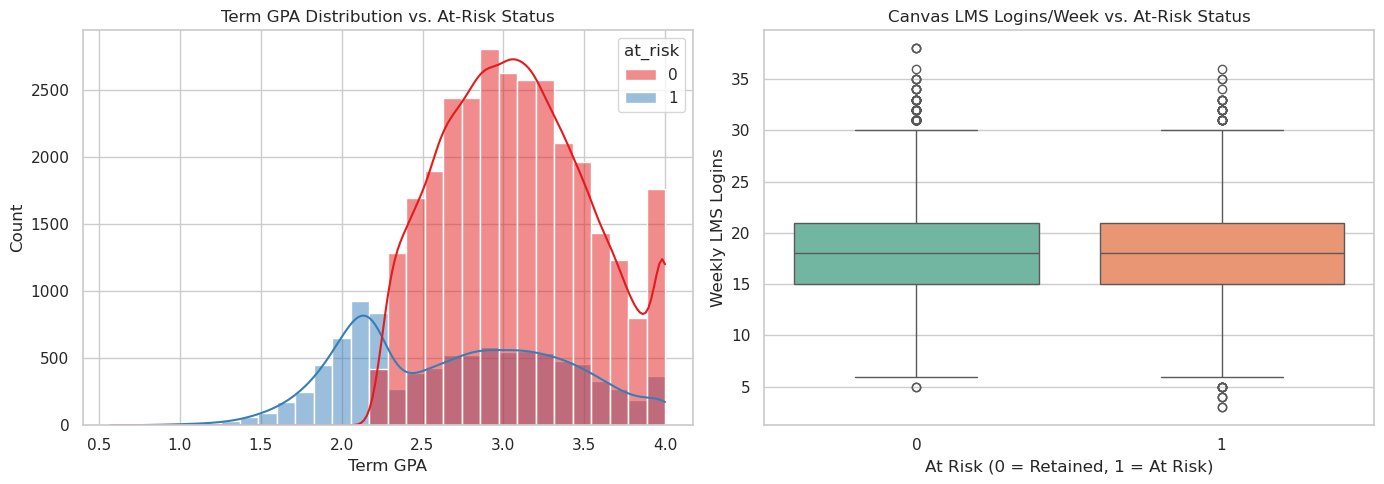

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Term GPA Distribution by Risk Status
sns.histplot(
    data=df,
    x="term_gpa",
    hue="at_risk",
    bins=30,
    kde=True,
    ax=axes[0],
    palette="Set1",
)
axes[0].set_title("Term GPA Distribution vs. At-Risk Status")
axes[0].set_xlabel("Term GPA")

# Plot 2: LMS Logins vs. Retention
sns.boxplot(
    data=df, x="at_risk", y="lms_logins_per_week", ax=axes[1], palette="Set2"
)
axes[1].set_title("Canvas LMS Logins/Week vs. At-Risk Status")
axes[1].set_xlabel("At Risk (0 = Retained, 1 = At Risk)")
axes[1].set_ylabel("Weekly LMS Logins")

plt.tight_layout()
plt.show()

Feature Correlation with Student Risk

In [ ]:
# Calculate correlations with target variable 'at_risk'
correlations = (
    df.corr(numeric_only=True)["at_risk"]
    .drop("at_risk")
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")
plt.title("Correlation of Features with Student At-Risk Status")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'SDSU-000001'